# Import modules

In [1]:
import numpy as np
import pandas as pd
import geojson
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import sys
sys.path.insert(0, '../')
from pysheds.grid import Grid
import seaborn as sns
from skimage import draw
import geopandas as gpd
from shapely import geometry, ops
import rasterio
from rasterio import features

%matplotlib inline

In [2]:
sns.set()
sns.set_palette('husl', 8)

# Create a flow direction grid from a raster

Data from USGS hydrosheds project: https://hydrosheds.cr.usgs.gov/datadownload.php

In [3]:
# Initialize grid from the ASCII file
grid = Grid.from_ascii('../data/dir.asc')

# Specify flow direction values

In [23]:
         #N    NE    E    SE    S    SW    W    NW
dirmap = (64,  128,  1,   2,    4,   8,    16,  32)

# Read the Flow Direction data into a variable
fdir = grid.read_ascii('../data/dir.asc', metadata={'dirmap': dirmap})

# Delineate catchment

In [24]:
# Specify pour point
x, y = -97.294167, 32.73750

# Delineate the catchment (returns a Raster object)
catch = grid.catchment(x=x, y=y, fdir=fdir, dirmap=dirmap, 
                       xytype='label', algorithm='iterative')

In [25]:
# Clip the bounding box to the catchment object
grid.clip_to(catch)

# Get catchment outline as vector polygon

In [26]:
# Polygonize the catchment mask
shapes = list(grid.polygonize())

# Merge all polygons into a single "Catchment Polygon"
catchment_polygon = ops.unary_union([geometry.shape(shape) for shape, value in shapes])

Text(0.5, 1.0, 'Catchment boundary (vector)')

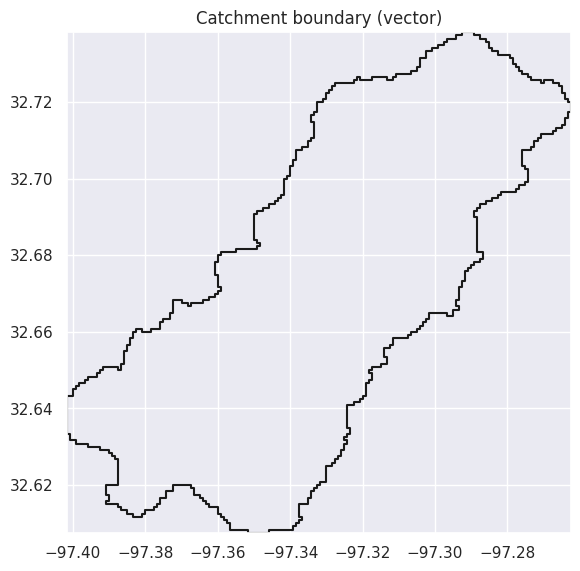

In [27]:
# Plot catchment boundaries
fig, ax = plt.subplots(figsize=(6.5, 6.5))

for shape in shapes:
    coords = np.asarray(shape[0]['coordinates'][0])
    ax.plot(coords[:,0], coords[:,1], color='k')
    
ax.set_xlim(grid.bbox[0], grid.bbox[2])
ax.set_ylim(grid.bbox[1], grid.bbox[3])
ax.set_title('Catchment boundary (vector)')

# Read soil type shapefile

In [ ]:
# soils = gpd.read_file('../data/nrcs-soils_48439_tarrant/')
# soil_id = 'MUKEY'
# soils = soils[soils.intersects(catchment_polygon)]
# catchment_soils = gpd.GeoDataFrame(soils[soil_id], geometry=soils.intersection(catchment_polygon))
# # Convert soil types to simple integer values
# soil_types = np.unique(catchment_soils[soil_id])
# soil_types = pd.Series(np.arange(soil_types.size), index=soil_types)
# catchment_soils[soil_id] = catchment_soils[soil_id].map(soil_types)

In [28]:
# 1. Create/Load Mock Soil Data covering the catchment extent
xmin, ymin, xmax, ymax = grid.bbox
cols = np.linspace(xmin, xmax, 5)
rows = np.linspace(ymin, ymax, 5)

polygons = []
mukey_values = []
for i in range(len(rows) - 1):
    for j in range(len(cols) - 1):
        polygons.append(geometry.box(cols[j], rows[i], cols[j+1], rows[i+1]))
        mukey_values.append(f"Soil_{i}_{j}")

soils = gpd.GeoDataFrame({'MUKEY': mukey_values, 'geometry': polygons}, crs=grid.crs)

# 2. Intersect soils with the catchment polygon
soil_id = 'MUKEY'
soils_subset = soils[soils.intersects(catchment_polygon)]
catchment_soils = gpd.GeoDataFrame(
    soils_subset[[soil_id]], 
    geometry=soils_subset.intersection(catchment_polygon)
)

In [29]:
# 1. Map string categories to integers for rasterization
unique_soils = catchment_soils[soil_id].unique()
soil_mapping = {name: i for i, name in enumerate(unique_soils)}
catchment_soils['mapped_id'] = catchment_soils[soil_id].map(soil_mapping)

# 2. Rasterize the soil data
soil_polygons = zip(catchment_soils.geometry, catchment_soils['mapped_id'])
soil_raster = grid.rasterize(soil_polygons, fill=np.nan, dtype=np.float64)

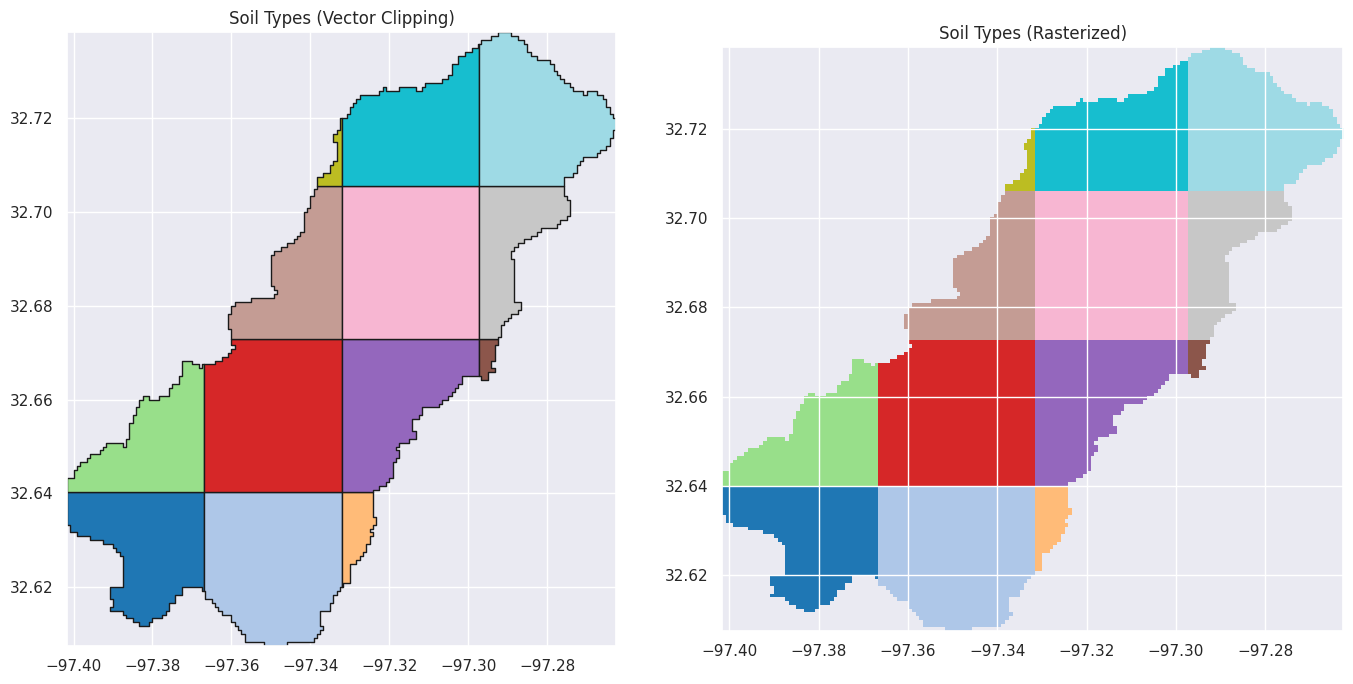

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Plot Vector Version
catchment_soils.plot(ax=ax[0], column=soil_id, categorical=True, cmap='tab20', edgecolor='k')
ax[0].set_title('Soil Types (Vector Clipping)')

# Plot Rasterized Version
im = ax[1].imshow(soil_raster, extent=grid.extent, cmap='tab20')
ax[1].set_title('Soil Types (Rasterized)')

for a in ax:
    a.set_xlim(grid.bbox[0], grid.bbox[2])
    a.set_ylim(grid.bbox[1], grid.bbox[3])

plt.tight_layout()

# Clip soil shapefile to catchment boundary

In [10]:
shapes = grid.polygonize()
catchment_polygon = ops.unary_union([geometry.shape(shape)
                                     for shape, value in shapes])

In [11]:
soil_id = 'MUKEY'
soils = soils[soils.intersects(catchment_polygon)]
catchment_soils = gpd.GeoDataFrame(soils[soil_id], geometry=soils.intersection(catchment_polygon))
# Convert soil types to simple integer values
soil_types = np.unique(catchment_soils[soil_id])
soil_types = pd.Series(np.arange(soil_types.size), index=soil_types)
catchment_soils[soil_id] = catchment_soils[soil_id].map(soil_types)

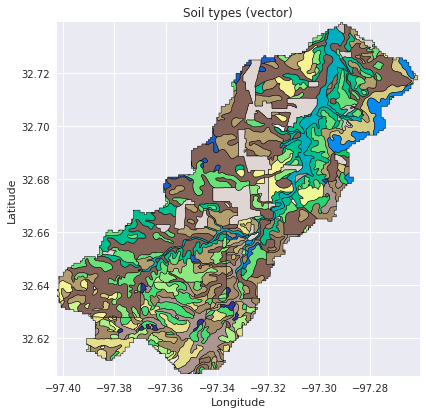

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
catchment_soils.plot(ax=ax, column=soil_id, categorical=True, cmap='terrain', linewidth=0.5, edgecolor='k', alpha=1)
ax.set_xlim(grid.bbox[0], grid.bbox[2])
ax.set_ylim(grid.bbox[1], grid.bbox[3])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
ax.set_title('Soil types (vector)')
plt.savefig('img/vector_soil.png')

# Rasterize soil data in catchment

In [13]:
soil_polygons = zip(catchment_soils.geometry.values, catchment_soils[soil_id].values)
soil_raster = grid.rasterize(soil_polygons, fill=np.nan)

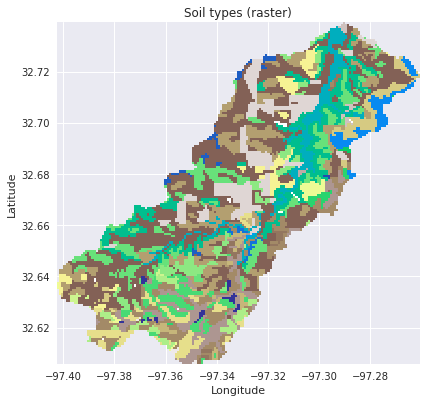

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
plt.imshow(soil_raster, cmap='terrain', extent=grid.extent, zorder=1)
ax.set_xlim(grid.bbox[0], grid.bbox[2])
ax.set_ylim(grid.bbox[1], grid.bbox[3])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
ax.set_title('Soil types (raster)')
plt.savefig('img/raster_soil.png')